INFO     | ======================================================================
INFO     | Starting analysis: figure_05_combined
INFO     | Log file: outputs/logs/figure_05_combined_20260623_113432.log
INFO     | Timestamp: 2026-06-23 11:34:32
INFO     | ======================================================================
INFO     | Configuration loaded — SPLIT_YEAR=2015, SHOW_TRENDS=True, REPROCESS=True
INFO     | Loading GLORYS12 data from: ../../glorys12_with_density/glorys12_*_Greenland_Sea_with_density.nc
INFO     |   33 files


/local/jbj13rpu/anaconda3/envs/env_25/lib/python3.10/site-packages/xarray/core/dataset.py:271: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/local/jbj13rpu/anaconda3/envs/env_25/lib/python3.10/site-packages/xarray/core/dataset.py:271: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/local/jbj13rpu/anaconda3/envs/env_25/lib/python3.10/site-packages/xarray/core/dataset.py:271: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/local/jbj13rpu/anaconda3/envs/env_25/lib/python3.10/site-packages/xarray/core/dataset.py:271: UserWarning: The specified

INFO     |   Time: 1993-01-01 → 2025-11-01
INFO     |   Density variable: 'absolute_density'
INFO     |   GS mask: 30508 cells
INFO     |   Total GS domain area: 657648 km²
INFO     | Loading ETOPO1 data from: rh.fetch_etopo1


/local/jbj13rpu/anaconda3/envs/env_25/lib/python3.10/site-packages/xarray/core/dataset.py:271: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


INFO     |   ETOPO1 loaded.
INFO     | Processing: Loading/computing map panels
INFO     | Processing: Extracting map panel 2018-03
INFO     | Created processed_data: psw_extent_febmar2018.nc
INFO     | Processing: Extracting map panel 2025-03
INFO     | Created processed_data: psw_extent_febmar2025.nc
INFO     | Processing: Computing scatter pairs
INFO     |   IGP: 190 profiles loaded
INFO     |   IGP2018: 29 scatter pairs
INFO     |   KH2025: 238 profiles loaded
INFO     |   KH2025: 191 scatter pairs
INFO     | Created processed_data: psw_scatter_v2_pairs_integration.csv
INFO     |   Scatter pairs: 220
INFO     | Processing: Computing monthly PSW timeseries
INFO     |   Timestep 1/395: 1993-01
INFO     |   Timestep 13/395: 1994-01
INFO     |   Timestep 25/395: 1995-01
INFO     |   Timestep 37/395: 1996-01
INFO     |   Timestep 49/395: 1997-01
INFO     |   Timestep 61/395: 1998-01
INFO     |   Timestep 73/395: 1999-01
INFO     |   Timestep 85/395: 2000-01
INFO     |   Timestep 97/395:

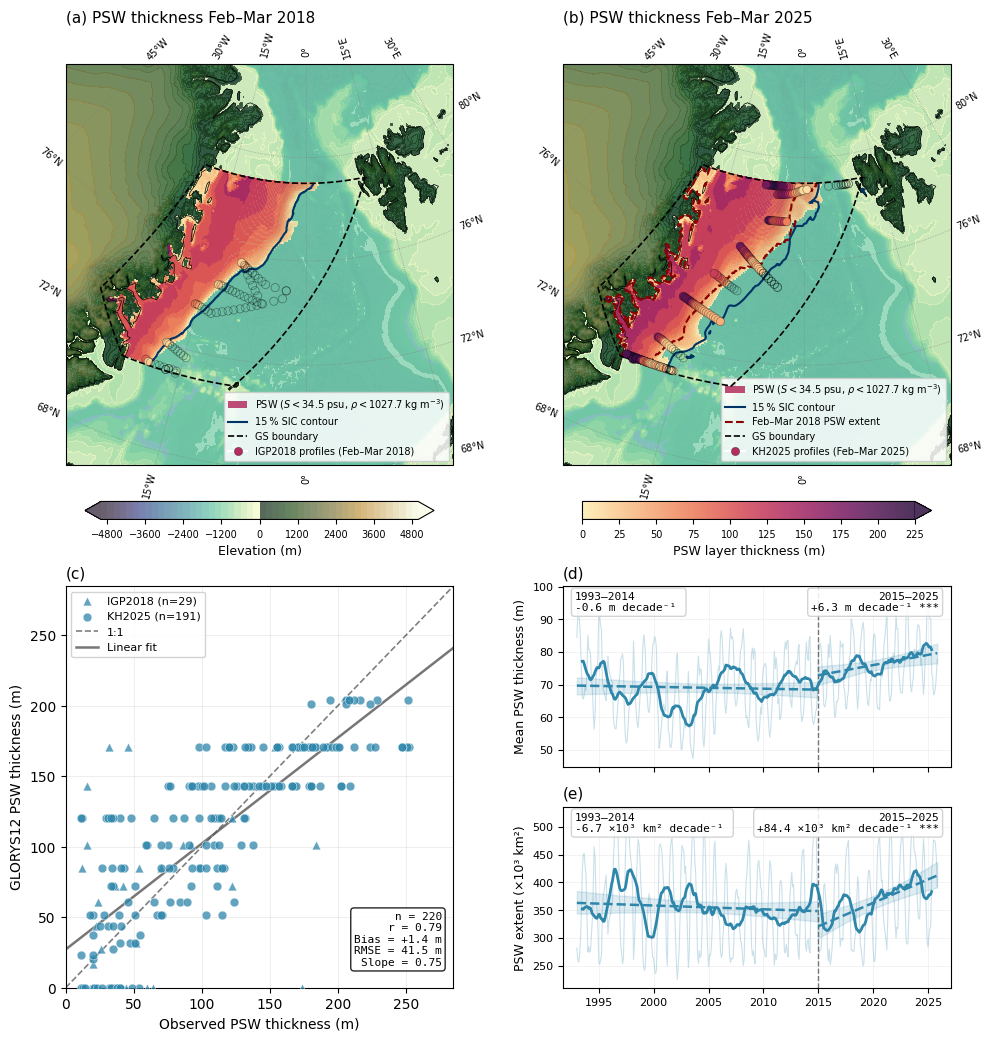

INFO     | ======================================================================
INFO     | Analysis completed successfully
INFO     | Total elapsed time: 0:05:01
INFO     | ======================================================================


In [1]:
"""
Figure 5 Combined: PSW Spatial Maps + Scatter + Timeseries
============================================================
5-panel figure layout:

  ┌──────────────────────┬──────────────────────┐
  │  (a) PSW map 2018    │  (b) PSW map 2025    │
  ├──────────────────────┼──────────────────────┤
  │                      │  (d) PSW thickness   │
  │  (c) Scatter         │      timeseries      │
  │      obs vs GLORYS   ├──────────────────────┤
  │                      │  (e) PSW extent      │
  └──────────────────────┴──────────────────────┘

PSW definition: S < 34.5 psu AND rho < 1027.7 kg/m³
PSW thickness: vertical integration via numpy.gradient(depth_vals)
PSW extent: sum of cell areas (km²) where PSW is present

Timeseries use monthly GLORYS12, 12-month rolling mean overlaid,
piecewise split-trend at SPLIT_YEAR with Mann-Kendall + bootstrap CI.

Outputs:
    outputs/figures/Figure5_PSW_combined.png
    outputs/figures/Figure5_PSW_combined.pdf
    outputs/processed_data/figure_05/psw_timeseries_monthly.csv
    outputs/processed_data/figure_05/psw_scatter_v2_pairs_integration.csv

Version: 1.1.0
"""

import sys
import yaml
import glob
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
from matplotlib.path import Path as MplPath
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.io import loadmat
from scipy import stats
from datetime import datetime, timezone, timedelta
from pathlib import Path

import cmocean
import rockhound as rh
import netCDF4 as nc
import gsw
import scipy.stats as _scipy_stats

# ── CHANGE 1: use pymannkendall with Yue & Wang (2004) correction ──────────
import pymannkendall as mk
# ───────────────────────────────────────────────────────────────────────────

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# ============================================================================
# LOAD CONFIG
# ============================================================================

config_path = Path(__file__).parent.parent / 'config.yaml' if '__file__' in dir() \
              else Path.cwd().parent / 'config.yaml'

with open(config_path) as f:
    config = yaml.safe_load(f)

sys.path.insert(0, str(config_path.parent))
from utils.logger import setup_logger, log_data_loading, log_processing_step, \
                         log_output_file, log_completion

start_time = datetime.now()
LOG_DIR = Path(config['paths']['logs'])
LOG_DIR.mkdir(parents=True, exist_ok=True)
log = setup_logger('figure_05_combined', config_path=str(config_path))

# ============================================================================
# PATHS & DIRECTORIES
# ============================================================================

GLORYS_PATH   = config['paths']['glorys12']
FIGURES_DIR   = Path(config['paths']['figures'])
PROCESSED_DIR = Path(config['paths']['processed_data']) / 'figure_05'
METHODS_DIR   = Path(config['paths']['methods'])

for d in (FIGURES_DIR, PROCESSED_DIR, METHODS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ============================================================================
# CONFIGURATION
# ============================================================================

REPROCESS = not config.get('processing', {}).get('use_cached_data', False)

# PSW thresholds
S_THRESHOLD   = config.get('analysis', {}).get('psw_salinity_threshold',   34.5)
RHO_THRESHOLD = config.get('analysis', {}).get('psw_density_threshold', 1027.7)

# Map panels
PANEL_MONTHS = [
    {'year': 2018, 'month': 3, 'label': '(a) PSW thickness Feb–Mar 2018',
     'cache': PROCESSED_DIR / 'psw_extent_febmar2018.nc'},
    {'year': 2025, 'month': 3, 'label': '(b) PSW thickness Feb–Mar 2025',
     'cache': PROCESSED_DIR / 'psw_extent_febmar2025.nc'},
]

# Observations
OBS_MIN_THICKNESS = 10.0   # m
IGP_MAT_DIR  = Path('/local/jbj13rpu/Documents/ROVER/IGP_data/'
                    'ALL0118_final_data/final_data/final_dco_files')
IGP_XCTD_MAT = Path('/local/jbj13rpu/Documents/ROVER/IGP_data/IGP_XCTD_data.mat')
IGP_GLORYS   = Path('/local/jbj13rpu/Documents/ROVER/IGP_data/glorys12/'
                    'glorys12_IGP_daily_FebMar2018.nc')
KH_MAT       = Path('/local/jbj13rpu/Documents/ROVER/KH_CTD/kh2025007002.mat')
KH_GLORYS    = Path('/local/jbj13rpu/Documents/ROVER/KH_CTD/glorys12/'
                    'glorys12_KH2025_daily_FebMar2025.nc')
IGP_OBS_NC   = Path('/local/jbj13rpu/Documents/ROVER/IGP_data/IGP_polar_water.nc')
KH_OBS_NC    = Path('/local/jbj13rpu/Documents/ROVER/KH_CTD/KH2025_polar_water.nc')

# Timeseries
SPLIT_YEAR    = 2015   # piecewise breakpoint (pre-specified on physical grounds)
SHOW_TRENDS   = True   # set False to suppress piecewise regression
N_BOOT        = 1000
ROLLING_WIN   = 12     # months

# Scatter
SCATTER_CSV   = PROCESSED_DIR / 'psw_scatter_v2_pairs_integration.csv'

# Timeseries cache
TS_CSV        = PROCESSED_DIR / 'psw_timeseries_monthly.csv'

# Map styling
SIC_THRESHOLD = config['analysis']['sic_threshold']
MAP_EXTENT    = [-25, 15, 68, 83]
RELIEF_ALPHA  = config['plotting'].get('relief_alpha', 0.70)
GREENLAND_SEA_COORDS = [tuple(c) for c in config['regions']['greenland_sea']['coords']]
COLOR_ICE_EDGE     = '#003366'
COLOR_2018_CONTOUR = '#8B0000'
COLOR_BOUNDARY     = 'black'
PSW_CMAP = cmocean.cm.matter
PSW_VMIN = 0.0
PSW_VMAX = 225.0

# Timeseries styling
COL_TS    = '#2E86AB'   # blue for both timeseries panels
COL_P1    = '#C62828'   # Period 1 trend (red)
COL_P2    = '#1565C0'   # Period 2 trend (blue)
COL_BP    = '#555555'   # breakpoint line
ALPHA_MONTHLY = 0.25
ALPHA_CI      = 0.15

# Scatter styling
COL_SCATTER = '#2E86AB'

log.info(f"Configuration loaded — SPLIT_YEAR={SPLIT_YEAR}, "
         f"SHOW_TRENDS={SHOW_TRENDS}, REPROCESS={REPROCESS}")

# ============================================================================
# EARTH RADIUS FOR CELL AREA CALCULATION
# ============================================================================

EARTH_RADIUS_KM = 6371.0

# ============================================================================
# GREENLAND SEA MASK
# ============================================================================

def make_gs_mask(lon2d, lat2d):
    poly = MplPath(GREENLAND_SEA_COORDS)
    pts  = np.column_stack([lon2d.ravel(), lat2d.ravel()])
    return poly.contains_points(pts).reshape(lon2d.shape)

# ============================================================================
# LOAD GLORYS12
# ============================================================================

log_data_loading(log, 'GLORYS12', GLORYS_PATH)
files = sorted(glob.glob(GLORYS_PATH))
if not files:
    raise FileNotFoundError(f"No GLORYS12 files at {GLORYS_PATH}")
log.info(f"  {len(files)} files")

ds = xr.open_mfdataset(files, combine='by_coords', parallel=False,
                        chunks={'time': 1})
log.info(f"  Time: {str(ds.time.values[0])[:10]} → {str(ds.time.values[-1])[:10]}")

_rho_candidates = ['absolute_density', 'density', 'rho', 'sigma0', 'sigma_theta',
                   'pot_density', 'sea_water_potential_density', 'rhopoto']
rho_var = next((v for v in _rho_candidates if v in ds), None)
if rho_var is None:
    raise KeyError(f"No density variable found. Available: {list(ds.data_vars)}")
log.info(f"  Density variable: '{rho_var}'")

lon1d = ds.longitude.values
lat1d = ds.latitude.values
lon2d_g, lat2d_g = np.meshgrid(lon1d, lat1d)
gs_mask = make_gs_mask(lon2d_g, lat2d_g)
log.info(f"  GS mask: {gs_mask.sum()} cells")

# Pre-compute cell areas (km²) — constant across time
dlon_deg = np.abs(np.gradient(lon1d))
dlat_deg = np.abs(np.gradient(lat1d))
dlon2d, dlat2d = np.meshgrid(dlon_deg, dlat_deg)
lat_rad = np.deg2rad(lat2d_g)
cell_area_km2 = (EARTH_RADIUS_KM ** 2
                 * np.deg2rad(dlat2d)
                 * np.deg2rad(dlon2d)
                 * np.abs(np.cos(lat_rad)))
log.info(f"  Total GS domain area: {cell_area_km2[gs_mask].sum():.0f} km²")

depth_vals = ds.depth.values
dz         = np.gradient(depth_vals)

# ============================================================================
# LOAD ETOPO1
# ============================================================================

log_data_loading(log, 'ETOPO1', 'rh.fetch_etopo1')
etopo        = rh.fetch_etopo1(version='ice')
etopo_sub    = etopo.sel(longitude=slice(-75, 75), latitude=slice(60, 90))
res          = 0.1
new_lons     = np.arange(etopo_sub.longitude.values[0],
                          etopo_sub.longitude.values[-1] + res, res)
new_lats     = np.arange(etopo_sub.latitude.values[0],
                          etopo_sub.latitude.values[-1] + res, res)
etopo_interp = etopo_sub.interp(longitude=new_lons, latitude=new_lats)
log.info("  ETOPO1 loaded.")

# ============================================================================
# HELPERS: GLORYS PSW EXTRACTION
# ============================================================================

def extract_psw_snapshot(year, month, cache_path):
    """PSW thickness and SIC for a single year/month (Feb-Mar mean)."""
    if not REPROCESS and cache_path.exists():
        cached = xr.open_dataset(cache_path)
        thickness = cached['psw_thickness'].values
        return thickness, np.isfinite(thickness), cached['sic'].values

    log_processing_step(log, f'Extracting map panel {year}-{month:02d}')
    feb_mar = ds.sel(time=slice(f'{year}-02', f'{year}-03'))
    snap    = feb_mar.mean(dim='time', skipna=True)

    so_3d  = snap['so'].values
    rho_3d = snap[rho_var].values
    sic    = snap['siconc'].values

    psw_3d = (so_3d < S_THRESHOLD) & (rho_3d < RHO_THRESHOLD)

    psw_thick = np.zeros((len(lat1d), len(lon1d)))
    for k, dz_k in enumerate(dz):
        psw_thick += np.where(psw_3d[k], dz_k, 0.0)
    psw_thick = np.where(psw_thick > 0, psw_thick, np.nan)
    psw_thick = np.where(gs_mask, psw_thick, np.nan)

    ds_out = xr.Dataset(
        {'psw_thickness': xr.DataArray(psw_thick, dims=['latitude', 'longitude'],
                                        attrs={'units': 'm'}),
         'sic':           xr.DataArray(sic,       dims=['latitude', 'longitude'],
                                        attrs={'units': '1'})},
        coords={'latitude': lat1d, 'longitude': lon1d},
    )
    ds_out.to_netcdf(cache_path)
    log_output_file(log, 'processed_data', str(cache_path))
    return psw_thick, np.isfinite(psw_thick), sic


def compute_monthly_timeseries():
    """Loop over all GLORYS12 monthly timesteps — compute mean PSW thickness and extent."""
    log_processing_step(log, 'Computing monthly PSW timeseries')
    times, mean_thick, extent_km2 = [], [], []

    n_times = len(ds.time)
    for i in range(n_times):
        if i % 12 == 0:
            log.info(f"  Timestep {i+1}/{n_times}: "
                     f"{str(ds.time.values[i])[:7]}")
        snap   = ds.isel(time=i)
        so_3d  = snap['so'].values
        rho_3d = snap[rho_var].values

        psw_3d = (so_3d < S_THRESHOLD) & (rho_3d < RHO_THRESHOLD)

        psw_thick = np.zeros((len(lat1d), len(lon1d)))
        for k, dz_k in enumerate(dz):
            psw_thick += np.where(psw_3d[k], dz_k, 0.0)
        psw_thick = np.where(psw_thick > 0, psw_thick, np.nan)
        psw_thick = np.where(gs_mask, psw_thick, np.nan)

        psw_mask_t = np.isfinite(psw_thick)

        mt   = np.nanmean(psw_thick[psw_mask_t]) if psw_mask_t.sum() > 0 else np.nan
        ext  = cell_area_km2[psw_mask_t].sum()

        times.append(pd.Timestamp(ds.time.values[i]))
        mean_thick.append(mt)
        extent_km2.append(ext)

    df = pd.DataFrame({'time': times,
                       'psw_mean_thickness_m': mean_thick,
                       'psw_extent_km2':       extent_km2})
    df.set_index('time', inplace=True)
    return df

# ============================================================================
# HELPERS: SCATTER PAIRS (integration method)
# ============================================================================

MATLAB_OFFSET = 719529

def dn_to_timestamp(dn):
    dt = datetime(1970, 1, 1, tzinfo=timezone.utc) + \
         timedelta(days=float(dn) - MATLAB_OFFSET)
    return pd.Timestamp(dt).normalize()


def psw_thickness_integration(depth_m, sal_psu, temp_c, lat, lon,
                               pressure_dbar=None, is_insitu=True):
    """Layer-integration PSW thickness from a single profile."""
    depth_m = np.asarray(depth_m, dtype=float)
    sal_psu = np.asarray(sal_psu, dtype=float)
    temp_c  = np.asarray(temp_c,  dtype=float)
    valid   = np.isfinite(depth_m) & np.isfinite(sal_psu) & np.isfinite(temp_c)
    if valid.sum() < 2:
        return 0.0
    d_v, s_v, t_v = depth_m[valid], sal_psu[valid], temp_c[valid]
    if pressure_dbar is not None:
        p_v = np.asarray(pressure_dbar, dtype=float)[valid]
    else:
        p_v = gsw.p_from_z(-d_v, lat)
    SA     = gsw.SA_from_SP(s_v, p_v, lon, lat)
    CT     = gsw.CT_from_t(SA, t_v, p_v) if is_insitu else gsw.CT_from_pt(SA, t_v)
    sig0   = gsw.sigma0(SA, CT)
    rho    = sig0 + 1000.0
    psw    = (s_v < S_THRESHOLD) & (rho < RHO_THRESHOLD)
    if not psw.any():
        return 0.0
    dz_prof = np.gradient(d_v)
    return max(float(np.sum(np.abs(dz_prof[psw]))), 0.0)


def load_igp_profiles():
    """Load IGP CTD (.dco) and XCTD (.mat) profiles."""
    profiles = []
    dco_files = sorted(glob.glob(str(IGP_MAT_DIR / '*.dco')))
    for fpath in dco_files:
        try:
            with open(fpath) as f:
                lines = f.readlines()
            meta  = lines[1].split()
            lat   = float(meta[1]);  lon = float(meta[3])
            ds_   = meta[5];  ts_ = meta[7]
            d, m, y = int(ds_[2:4]), int(ds_[:2]), int(ds_[4:6])
            y += 2000 if y < 50 else 1900
            h, mn = int(ts_.split(':')[0]), int(ts_.split(':')[1])
            ts = pd.Timestamp(y, m, d, h, mn, tzinfo=timezone.utc).normalize()
            arr   = np.array([[float(x) for x in row.split()[:3]]
                               for row in lines[3:] if row.strip()])
            profiles.append({'lon': lon, 'lat': lat, 'time': ts,
                              'depth': arr[:, 0], 'temp': arr[:, 1],
                              'sal': arr[:, 2], 'pressure': arr[:, 0],
                              'source': 'IGP CTD'})
        except Exception:
            pass

    if IGP_XCTD_MAT.exists():
        raw  = loadmat(str(IGP_XCTD_MAT), squeeze_me=False)
        data = raw['xctd'][0, 0]['final'][0, 0]['data'][0, 0]
        n    = data.shape[0]
        dgrid = data['dep'][0, 0].ravel().astype(float)
        for i in range(n):
            try:
                lat_  = float(data['lat'][i, 0].squeeze())
                lon_  = float(data['lon'][i, 0].squeeze())
                dn    = float(data['date'][i, 0].squeeze())
                ts    = dn_to_timestamp(dn)
                temp_ = data['tem_final_2m'][i, 0].ravel().astype(float)
                sal_  = data['sal_final_2m'][i, 0].ravel().astype(float)
                n_d   = len(dgrid)
                temp_ = np.concatenate([temp_, np.full(max(0, n_d-len(temp_)), np.nan)])[:n_d]
                sal_  = np.concatenate([sal_,  np.full(max(0, n_d-len(sal_)),  np.nan)])[:n_d]
                profiles.append({'lon': lon_, 'lat': lat_, 'time': ts,
                                  'depth': dgrid.copy(), 'temp': temp_,
                                  'sal': sal_, 'pressure': None,
                                  'source': 'IGP XCTD'})
            except Exception:
                pass
    log.info(f"  IGP: {len(profiles)} profiles loaded")
    return profiles


def load_kh2025_profiles():
    """Load KH2025 CTD profiles from .mat file."""
    raw  = loadmat(str(KH_MAT), squeeze_me=False)
    key  = [k for k in raw.keys() if not k.startswith('_')][0]
    data = raw[key].squeeze()
    profiles = []
    for i in range(data.shape[0]):
        try:
            lon_  = float(data['lon'][i].squeeze())
            lat_  = float(data['lat'][i].squeeze())
            dn    = float(data['time'][i].squeeze())
            press = data['press'][i].squeeze().astype(float)
            temp_ = data['temp'][i].squeeze().astype(float)
            sal_  = data['sal'][i].squeeze().astype(float)
            profiles.append({'lon': lon_, 'lat': lat_, 'time': dn_to_timestamp(dn),
                              'depth': press, 'temp': temp_, 'sal': sal_,
                              'pressure': press, 'source': 'KH2025 CTD'})
        except Exception:
            pass
    log.info(f"  KH2025: {len(profiles)} profiles loaded")
    return profiles


def collocate_glorys_scatter(profiles, glorys_file, campaign_label):
    """Collocate daily GLORYS12 to profile positions and compute PSW thickness."""
    ds_g     = xr.open_dataset(str(glorys_file))
    lat_name = 'latitude'  if 'latitude'  in ds_g.coords else 'lat'
    lon_name = 'longitude' if 'longitude' in ds_g.coords else 'lon'
    gl_times = pd.to_datetime(ds_g['time'].values)
    gl_depth = ds_g['depth'].values.copy()
    if gl_depth[0] < 0:
        gl_depth = -gl_depth

    records = []
    for p in profiles:
        obs_thick = psw_thickness_integration(
            p['depth'], p['sal'], p['temp'], p['lat'], p['lon'],
            pressure_dbar=p['pressure'], is_insitu=True)
        if obs_thick <= OBS_MIN_THICKNESS:
            continue

        t = p['time']
        idx = np.where((gl_times.year  == t.year) &
                       (gl_times.month == t.month) &
                       (gl_times.day   == t.day))[0]
        if len(idx) == 0:
            continue
        sl = ds_g.isel(time=idx[0])
        try:
            prof = sl.interp({lat_name: float(p['lat']),
                               lon_name: float(p['lon'])}, method='linear')
        except Exception:
            try:
                prof = sl.sel({lat_name: float(p['lat']),
                                lon_name: float(p['lon'])}, method='nearest')
            except Exception:
                continue

        sal_g   = prof['so'].values
        theta_g = prof['thetao'].values
        g_thick = psw_thickness_integration(
            gl_depth, sal_g, theta_g, p['lat'], p['lon'],
            pressure_dbar=None, is_insitu=False)

        records.append({'campaign': campaign_label, 'source': p['source'],
                        'lon': p['lon'], 'lat': p['lat'], 'date': t,
                        'obs_thickness': obs_thick, 'glorys_thickness': g_thick})
    ds_g.close()
    log.info(f"  {campaign_label}: {len(records)} scatter pairs")
    return records


def compute_scatter_pairs():
    """Build scatter pairs for both campaigns."""
    log_processing_step(log, 'Computing scatter pairs')
    records = []
    if IGP_MAT_DIR.exists() and IGP_GLORYS.exists():
        # ── CHANGE 4b: campaign label 'IGP 2018' → 'IGP2018' ───────────────
        records += collocate_glorys_scatter(load_igp_profiles(), IGP_GLORYS, 'IGP2018')
    else:
        log.warning('IGP files not found — scatter will be KH2025 only')
    if KH_MAT.exists() and KH_GLORYS.exists():
        records += collocate_glorys_scatter(load_kh2025_profiles(), KH_GLORYS, 'KH2025')
    else:
        log.warning('KH2025 files not found — scatter incomplete')
    df = pd.DataFrame(records)
    df.to_csv(SCATTER_CSV, index=False)
    log_output_file(log, 'processed_data', str(SCATTER_CSV))
    return df

# ============================================================================
# HELPERS: STATISTICS
# ============================================================================

def compute_split_trends(series, split_year=SPLIT_YEAR, n_boot=N_BOOT):
    """
    Piecewise linear regression at split_year with Yue & Wang (2004) modified
    Mann-Kendall and bootstrap 95% CI. Returns dict with keys 'p1', 'p2'.

    Period 1: year < split_year  (inclusive — breakpoint year in both periods)
    Period 2: year >= split_year  (inclusive — breakpoint year in both periods)

    References
    ----------
    Yue, S., & Wang, C. (2004). Water Resources Management, 18(3), 201-218.
    https://doi.org/10.1023/B:WARM.0000043140.61082.60
    """
    results = {}
    for period, mask in [
        ('p1', series.index.year < split_year),
        ('p2', series.index.year >= split_year),
    ]:
        sub = series[mask].dropna()
        if len(sub) < 6:
            results[period] = None
            continue
        x = sub.index.year + (sub.index.month - 1) / 12.0
        y = sub.values
        slope, intercept, _, _, _ = stats.linregress(x, y)
        fitted = slope * x + intercept
        # ── CHANGE 2b: Yue & Wang (2004) modified MK ─────────────────────
        mk_res = mk.yue_wang_modification_test(y)

        # Bootstrap CI
        boot_slopes = []
        rng = np.random.default_rng(42)
        for _ in range(n_boot):
            idx    = rng.integers(0, len(x), len(x))
            bs, bi, *_ = stats.linregress(x[idx], y[idx])
            boot_slopes.append(bs * x + bi)
        ci_lo = np.percentile(boot_slopes, 2.5,  axis=0)
        ci_hi = np.percentile(boot_slopes, 97.5, axis=0)

        sig = ('***' if mk_res.p <= 0.001 else
               '**'  if mk_res.p <= 0.01  else
               '*'   if mk_res.p <= 0.05  else '')

        results[period] = {
            'sub': sub, 'x': x, 'fitted': fitted,
            'slope': slope * 10,   # per decade
            'ci_lo': ci_lo, 'ci_hi': ci_hi,
            'mk': mk_res, 'sig': sig,
        }
    return results


def stats_box(r, label, trend_units=''):
    """One-line stats string for annotation box."""
    if r is None:
        return ''
    trend_str = f"{r['slope']:+.1f} {trend_units} decade\u207b\u00b9"
    return f"{label}\n{trend_str} {r['sig']}"

# ============================================================================
# HELPERS: MAP UTILITIES
# ============================================================================

def densify_poly(coords, n=100):
    lons, lats = [], []
    for i in range(len(coords) - 1):
        lo0, la0 = coords[i];  lo1, la1 = coords[i + 1]
        lons.extend(np.linspace(lo0, lo1, n, endpoint=False))
        lats.extend(np.linspace(la0, la1, n, endpoint=False))
    lons.append(coords[-1][0]);  lats.append(coords[-1][1])
    return lons, lats


def load_obs_pw_nc(filepath):
    if not Path(filepath).exists():
        return None, None, None
    with nc.Dataset(filepath) as d:
        return (d['lon'][:].data.copy(), d['lat'][:].data.copy(),
                d['pw_thickness'][:].data.copy())


def plot_obs_dots(ax, lon, lat, thickness, pc):
    if lon is None:
        return
    poly   = MplPath(GREENLAND_SEA_COORDS)
    in_gs  = poly.contains_points(np.column_stack([lon, lat]))
    lg, ltg, tg = lon[in_gs], lat[in_gs], thickness[in_gs]
    has    = tg > OBS_MIN_THICKNESS
    if has.sum() > 0:
        ax.scatter(lg[has], ltg[has], c=tg[has], cmap=PSW_CMAP,
                   vmin=PSW_VMIN, vmax=PSW_VMAX, s=35, transform=pc,
                   zorder=9, linewidths=0.5, edgecolors=(0,0,0,0.4))
    if (~has).sum() > 0:
        ax.scatter(lg[~has], ltg[~has], facecolors='none',
                   edgecolors=(0,0,0,0.4), linewidths=0.5, s=35,
                   transform=pc, zorder=9)

# ============================================================================
# DATA LOADING / PROCESSING
# ============================================================================

log_processing_step(log, 'Loading/computing map panels')
panel_data = []
for panel in PANEL_MONTHS:
    thick, mask, sic = extract_psw_snapshot(panel['year'], panel['month'],
                                             panel['cache'])
    panel_data.append({'thickness': thick, 'mask': mask, 'sic': sic, **panel})

psw_mask_2018 = panel_data[0]['mask']
bathy_levels  = np.arange(-5000, 5200, 200)
poly_lons_d, poly_lats_d = densify_poly(GREENLAND_SEA_COORDS)

igp_lon, igp_lat, igp_thick = load_obs_pw_nc(IGP_OBS_NC)
kh_lon,  kh_lat,  kh_thick  = load_obs_pw_nc(KH_OBS_NC)

# Scatter pairs
if not REPROCESS and SCATTER_CSV.exists():
    log.info('Loading cached scatter pairs')
    df_scatter = pd.read_csv(SCATTER_CSV, parse_dates=['date'])
else:
    df_scatter = compute_scatter_pairs()

log.info(f"  Scatter pairs: {len(df_scatter)}")

# Monthly timeseries
if not REPROCESS and TS_CSV.exists():
    log.info('Loading cached timeseries')
    df_ts = pd.read_csv(TS_CSV, parse_dates=['time'], index_col='time')
else:
    df_ts = compute_monthly_timeseries()
    df_ts.to_csv(TS_CSV)
    log_output_file(log, 'processed_data', str(TS_CSV))

log.info(f"  Timeseries: {len(df_ts)} months, "
         f"{str(df_ts.index[0])[:7]} → {str(df_ts.index[-1])[:7]}")

# Rolling means — first/last 6 months masked to avoid edge artefacts
HALF_WIN = ROLLING_WIN // 2   # 6 months
df_ts['thick_roll'] = (df_ts['psw_mean_thickness_m']
                       .rolling(ROLLING_WIN, center=True, min_periods=6).mean())
df_ts['extent_roll'] = (df_ts['psw_extent_km2']
                        .rolling(ROLLING_WIN, center=True, min_periods=6).mean())
df_ts.loc[df_ts.index[:HALF_WIN], ['thick_roll', 'extent_roll']] = np.nan
df_ts.loc[df_ts.index[-HALF_WIN:], ['thick_roll', 'extent_roll']] = np.nan

# Split trends
trends_d = compute_split_trends(df_ts['psw_mean_thickness_m'])
trends_e = compute_split_trends(df_ts['psw_extent_km2'])

# Scatter statistics
def scatter_stats(obs, glo):
    m = np.isfinite(obs) & np.isfinite(glo)
    o, g = obs[m], glo[m]
    r, p = stats.pearsonr(o, g)
    bias  = float(np.mean(g - o))
    rmse  = float(np.sqrt(np.mean((g - o) ** 2)))
    sl, ic, *_ = stats.linregress(o, g)
    return dict(n=len(o), r=r, p=p, bias=bias, rmse=rmse, slope=sl, intercept=ic)

sc_stats = scatter_stats(df_scatter['obs_thickness'].values,
                          df_scatter['glorys_thickness'].values)

# ============================================================================
# BUILD FIGURE
# ============================================================================

log_processing_step(log, 'Building figure')

fig = plt.figure(figsize=(12, 12))

outer = gridspec.GridSpec(2, 2, figure=fig,
                           height_ratios=[1.0, 1.0],
                           hspace=0.3, wspace=0.15)

proj = ccrs.NorthPolarStereo(central_longitude=0)
pc   = ccrs.PlateCarree()
ax_a = fig.add_subplot(outer[0, 0], projection=proj)
ax_b = fig.add_subplot(outer[0, 1], projection=proj)
ax_c = fig.add_subplot(outer[1, 0])

inner = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=outer[1, 1], hspace=0.22)
ax_d = fig.add_subplot(inner[0])
ax_e = fig.add_subplot(inner[1])

# ============================================================================
# PANELS (a) and (b) — MAPS
# ============================================================================

for i, (ax, pdata) in enumerate(zip([ax_a, ax_b], panel_data)):
    ax.set_extent(MAP_EXTENT, crs=pc)
    ax.coastlines(resolution='50m', linewidth=0.5, color='black', zorder=5)

    relief = ax.contourf(etopo_interp.longitude, etopo_interp.latitude,
                          etopo_interp.ice, transform=pc,
                          levels=bathy_levels, cmap=cmocean.cm.topo,
                          alpha=RELIEF_ALPHA, extend='both', zorder=1)

    thickness_plot = np.where(pdata['mask'], pdata['thickness'], np.nan)
    psw_im = ax.pcolormesh(lon1d, lat1d, thickness_plot, transform=pc,
                            cmap=PSW_CMAP, vmin=PSW_VMIN, vmax=PSW_VMAX,
                            alpha=0.85, shading='auto', zorder=3)

    if i == 1:
        ax.contour(lon1d, lat1d, psw_mask_2018.astype(float),
                   levels=[0.5], transform=pc, colors=[COLOR_2018_CONTOUR],
                   linewidths=1.5, linestyles='--', zorder=7)

    ax.contour(lon1d, lat1d, pdata['sic'], levels=[SIC_THRESHOLD],
               transform=pc, colors=[COLOR_ICE_EDGE], linewidths=1.5,
               linestyles='-', zorder=6)

    if i == 0:
        plot_obs_dots(ax, igp_lon, igp_lat, igp_thick, pc)
    else:
        plot_obs_dots(ax, kh_lon, kh_lat, kh_thick, pc)

    ax.plot(poly_lons_d, poly_lats_d, transform=pc, color=COLOR_BOUNDARY,
            linewidth=1.2, linestyle='--', zorder=8)

    gl = ax.gridlines(crs=pc, draw_labels=True, x_inline=False, y_inline=False,
                       linewidth=0.5, color='gray', alpha=0.85, linestyle=':',
                       zorder=20)
    gl.xlocator     = mticker.FixedLocator(np.arange(-90, 91, 15))
    gl.ylocator     = mticker.FixedLocator(np.arange(60, 91, 4))
    gl.xformatter   = LongitudeFormatter()
    gl.yformatter   = LatitudeFormatter()
    gl.top_labels = gl.bottom_labels = gl.left_labels = gl.right_labels = True
    gl.xlabel_style = gl.ylabel_style = {'size': 7}
    ax.set_title(pdata['label'], loc='left', fontsize=11, fontweight='normal')

# Map colorbars
fig.canvas.draw()
for ax_map, im, label in [(ax_a, relief, 'Elevation (m)'),
                            (ax_b, psw_im, 'PSW layer thickness (m)')]:
    pos = ax_map.get_position()
    cax = fig.add_axes([pos.x0 + pos.width * 0.05, pos.y0 - 0.045,
                         pos.width * 0.90, 0.015])
    extend = 'both' if label == 'Elevation (m)' else 'max'
    cb = plt.colorbar(im, cax=cax, orientation='horizontal', extend=extend)
    cb.set_label(label, fontsize=9)
    cb.ax.tick_params(labelsize=7)

# Map legends
_h_psw  = Patch(facecolor=PSW_CMAP(0.6), alpha=0.85,
                label=fr'PSW ($S<{S_THRESHOLD}$ psu, $\rho<{RHO_THRESHOLD}$ kg m$^{{-3}}$)')
_h_sic  = Line2D([0],[0], color=COLOR_ICE_EDGE, lw=1.5,
                 label=f'{int(SIC_THRESHOLD*100)}\u202f% SIC contour')
_h_gs   = Line2D([0],[0], color=COLOR_BOUNDARY, lw=1.2, ls='--',
                 label='GS boundary')
# ── CHANGE 4a: 'IGP profiles' → 'IGP2018 profiles' ──────────────────────
_h_igp  = Line2D([0],[0], marker='o', color='w', markersize=6,
                 markerfacecolor=PSW_CMAP(0.6), markeredgecolor=(0,0,0,0.4),
                 markeredgewidth=0.5, label='IGP2018 profiles (Feb–Mar 2018)')
_h_kh   = Line2D([0],[0], marker='o', color='w', markersize=6,
                 markerfacecolor=PSW_CMAP(0.6), markeredgecolor=(0,0,0,0.4),
                 markeredgewidth=0.5, label='KH2025 profiles (Feb–Mar 2025)')
_h_2018 = Line2D([0],[0], color=COLOR_2018_CONTOUR, lw=1.5, ls='--',
                 label='Feb–Mar 2018 PSW extent')

ax_a.legend(handles=[_h_psw, _h_sic, _h_gs, _h_igp],
            loc='lower right', fontsize=7, framealpha=0.85)
ax_b.legend(handles=[_h_psw, _h_sic, _h_2018, _h_gs, _h_kh],
            loc='lower right', fontsize=7, framealpha=0.85)

# ============================================================================
# PANEL (c) — SCATTER
# ============================================================================

all_max = max(df_scatter['obs_thickness'].max(),
              df_scatter['glorys_thickness'].max())
lim = np.ceil(all_max / 25) * 25 + 10

# ── CHANGE 4b: 'IGP 2018' → 'IGP2018' in scatter loop ───────────────────
for campaign, marker in [('IGP2018', '^'), ('KH2025', 'o')]:
    sub = df_scatter[df_scatter['campaign'] == campaign]
    if sub.empty:
        continue
    ax_c.scatter(sub['obs_thickness'], sub['glorys_thickness'],
                 c=COL_SCATTER, marker=marker, s=40, alpha=0.75,
                 linewidths=0.4, edgecolors='white', zorder=3,
                 label=f'{campaign} (n={len(sub)})')

ax_c.plot([0, lim], [0, lim], 'k--', lw=1.2, alpha=0.5, zorder=2, label='1:1')
if sc_stats['n'] >= 3:
    xf = np.array([0, lim])
    ax_c.plot(xf, sc_stats['slope'] * xf + sc_stats['intercept'],
              '-', color='#555555', lw=1.8, alpha=0.8, zorder=2, label='Linear fit')

ax_c.text(0.97, 0.05,
          f"n = {sc_stats['n']}\n"
          f"r = {sc_stats['r']:.2f}\n"
          f"Bias = {sc_stats['bias']:+.1f} m\n"
          f"RMSE = {sc_stats['rmse']:.1f} m\n"
          f"Slope = {sc_stats['slope']:.2f}",
          transform=ax_c.transAxes, fontsize=8, va='bottom', ha='right',
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
          family='monospace')

ax_c.set_xlim(0, lim);  ax_c.set_ylim(0, lim)
ax_c.set_xlabel('Observed PSW thickness (m)', fontsize=10)
ax_c.set_ylabel('GLORYS12 PSW thickness (m)', fontsize=10)
ax_c.set_title('(c)', loc='left', fontsize=11, fontweight='normal')
ax_c.grid(True, alpha=0.3, lw=0.5)
ax_c.legend(fontsize=8, loc='upper left', framealpha=0.85)

# ============================================================================
# HELPER: draw one timeseries panel
# ============================================================================

def draw_ts_panel(ax, series, roll, trend_res, panel_label,
                  ylabel, unit_label, col, trend_units=''):
    """Monthly dots + rolling mean + optional split trends + stats boxes."""
    # Monthly background
    ax.plot(series.index, series.values, color=col, alpha=ALPHA_MONTHLY,
            lw=0.8, zorder=2)

    # 12-month rolling mean
    ax.plot(roll.index, roll.values, color=col, lw=2.0, zorder=3)

    if SHOW_TRENDS and trend_res:
        for period, xpos, ha in [('p1', 0.03, 'left'), ('p2', 0.97, 'right')]:
            r = trend_res.get(period)
            if r is None:
                continue
            t_idx = r['sub'].index
            ax.plot(t_idx, r['fitted'], color=col, lw=1.8, ls='--', zorder=4)
            ax.fill_between(t_idx, r['ci_lo'], r['ci_hi'],
                             color=col, alpha=ALPHA_CI, zorder=2)
            yr0 = r['sub'].index[0].year
            yr1 = r['sub'].index[-1].year
            txt = stats_box(r, f"{yr0}–{yr1}", trend_units)
            ax.text(xpos, 0.97, txt, transform=ax.transAxes, fontsize=8,
                    va='top', ha=ha, family='monospace',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              edgecolor='#cccccc', alpha=0.85))

    # Breakpoint line
    ax.axvline(pd.Timestamp(f'{SPLIT_YEAR}-01-01'), color=COL_BP,
               ls='--', lw=1.0, alpha=0.8, zorder=2)

    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(panel_label, loc='left', fontsize=11, fontweight='normal')
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.25, lw=0.4)
    # ── CHANGE 3: 1 year padding on each side instead of 3 months ────────
    ax.set_xlim(series.index.min() - pd.DateOffset(months=15),
                series.index.max() + pd.DateOffset(months=15))

# ============================================================================
# PANELS (d) and (e) — TIMESERIES
# ============================================================================

draw_ts_panel(ax_d,
              df_ts['psw_mean_thickness_m'],
              df_ts['thick_roll'],
              trends_d,
              '(d)',
              'Mean PSW thickness (m)',
              'm', COL_TS, trend_units='m')

draw_ts_panel(ax_e,
              df_ts['psw_extent_km2'] / 1e3,
              df_ts['extent_roll'] / 1e3,
              {k: ({**v,
                    'fitted': v['fitted'] / 1e3,
                    'ci_lo':  v['ci_lo']  / 1e3,
                    'ci_hi':  v['ci_hi']  / 1e3,
                    'slope':  v['slope']  / 1e3,
                    'sub':    v['sub']    / 1e3} if v else None)
               for k, v in trends_e.items()},
              '(e)',
              'PSW extent (\u00d710\u00b3 km\u00b2)',
              '\u00d710\u00b3 km\u00b2', COL_TS,
              trend_units='\u00d710\u00b3 km\u00b2')

import matplotlib.dates as mdates

fig.canvas.draw()
pos_a = ax_a.get_position()
pos_b = ax_b.get_position()

pos_c = ax_c.get_position()
ax_c.set_position([pos_a.x0, pos_c.y0, pos_a.width, pos_c.height])

pos_d = ax_d.get_position()
pos_e = ax_e.get_position()
ts_left  = pos_b.x0
ts_width = pos_b.width
ax_d.set_position([ts_left, pos_d.y0, ts_width, pos_d.height])
ax_e.set_position([ts_left, pos_e.y0, ts_width, pos_e.height])

ax_d.sharex(ax_e)
plt.setp(ax_d.get_xticklabels(), visible=False)
ax_e.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_e.xaxis.set_major_locator(mdates.YearLocator(5))
ax_e.tick_params(axis='x', labelsize=8)

# ============================================================================
# SAVE
# ============================================================================

for ext in ('png', 'pdf'):
    out = FIGURES_DIR / f'Figure5_PSW_combined.{ext}'
    dpi = 600 if ext == 'png' else None
    fig.savefig(out, dpi=dpi, bbox_inches='tight')
    log_output_file(log, 'figure', str(out))
    log.info(f"  Saved: {out}")

plt.show()
log_completion(log, start_time)